# Final Project Notebook
# TD1: Data Acquisition and Information Extraction
## Installation and Imports

In [1]:
!pip install "trafilatura[all]" lxml_html_clean spacy pandas httpx
!python -m spacy download en_core_web_trf

import trafilatura
import json
import spacy
import pandas as pd
import httpx
import time

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 317.1/317.1 kB 18.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 837.9/837.9 kB 34.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 746.1/746.1 kB 48.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4.9/4.9 MB 62.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 132.6/132.6 kB 11.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 318.7/318.7 kB 17.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 296.7/296.7 kB 17.9 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 457.4/457.4 MB 2.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 237.9/237.9 kB 9.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 734.0/734.0 kB 46.6 MB/s eta 0:00:00
✔ Download and installation successful
You can now load the package via spacy.load('en_core_web_trf')
⚠ Restart to reload dependencies
If you are in a Jupyter or Colab notebook, you may need to r

## Phase 1: Web Crawling & Cleaning
This step uses `trafilatura` to extract the main content of web pages by ignoring noise (menus, footers). We filter pages with fewer than 500 words to ensure the richness of the extracted text.

In [2]:
urls = [
    "https://www.ukri.org/opportunity/fundamental-ai-research-lab/",
    "https://rea.ec.europa.eu/research-and-artificial-intelligence_en",
    "https://www.theguardian.com/technology/2025/dec/06/ai-research-papers",
    "https://www.nsf.gov/focus-areas/ai/nairr",
    "https://scienceexchange.caltech.edu/topics/artificial-intelligence-research"
]

def is_useful(text):
    if text is None:
        return False
    return len(text.split()) > 500

def process_urls(url_list, output_file='crawler_output.jsonl'):
    with open(output_file, 'w', encoding='utf-8') as f:
        for url in url_list:
            downloaded = trafilatura.fetch_url(url)
            if downloaded:
                content = trafilatura.extract(downloaded)
                if is_useful(content):
                    json_line = json.dumps({"url": url, "text": content}, ensure_ascii=False)
                    f.write(json_line + '\n')
                    print(f"Successful extraction: {url}")
                else:
                    print(f"Page ignored (< 500 words): {url}")
            else:
                print(f"Download failed: {url}")

process_urls(urls)

Successful extraction: https://www.ukri.org/opportunity/fundamental-ai-research-lab/
Successful extraction: https://rea.ec.europa.eu/research-and-artificial-intelligence_en
Successful extraction: https://www.theguardian.com/technology/2025/dec/06/ai-research-papers
Successful extraction: https://www.nsf.gov/focus-areas/ai/nairr
Successful extraction: https://scienceexchange.caltech.edu/topics/artificial-intelligence-research


## Phase 2: Information Extraction (NER and Relations)
We use the spaCy Transformer model (`en_core_web_trf`) to identify named entities (NER) and analyze syntactic dependencies. Extracting relations between entities will enable the creation of an initial graph that is richer than simple type declarations.

In [3]:
nlp = spacy.load("en_core_web_trf")

def extract_knowledge_and_relations(input_file, entities_output, relations_output):
    knowledge_data = []
    relations_data = []

    with open(input_file, 'r', encoding='utf-8') as f:
        for line in f:
            item = json.loads(line)
            doc = nlp(item['text'])

            # 1. Entity extraction
            entities_in_doc = {}
            for ent in doc.ents:
                if ent.label_ in ["PERSON", "ORG", "GPE", "DATE"]:
                    clean_text = ent.text.strip().replace('\n', ' ')
                    entities_in_doc[clean_text] = ent.label_
                    knowledge_data.append({
                        "Entity": clean_text,
                        "Type": ent.label_,
                        "Source URL": item['url']
                    })

            # 2. Dependency-based relation extraction (Subject - Verb - Object)
            for sent in doc.sents:
                for token in sent:
                    if token.pos_ == "VERB":
                        subj = [w.text.strip() for w in token.lefts if w.dep_ in ("nsubj", "nsubjpass")]
                        obj = [w.text.strip() for w in token.rights if w.dep_ in ("dobj", "pobj")]

                        if subj and obj:
                            s, o = subj[0], obj[0]
                            # Only keep the relation if the subject or object is a recognized entity
                            if s in entities_in_doc or o in entities_in_doc:
                                relations_data.append({
                                    "Subject": s,
                                    "Predicate": token.lemma_,
                                    "Object": o,
                                    "Source URL": item['url']
                                })

    # Save entities
    df_entities = pd.DataFrame(knowledge_data).drop_duplicates()
    df_entities.to_csv(entities_output, index=False, encoding='utf-8')

    # Save relations
    df_relations = pd.DataFrame(relations_data).drop_duplicates()
    df_relations.to_csv(relations_output, index=False, encoding='utf-8')

    return df_entities, df_relations

df_entities, df_relations = extract_knowledge_and_relations(
    'crawler_output.jsonl',
    'extracted_knowledge.csv',
    'extracted_relations.csv'
)
print(f"Extracted entities: {len(df_entities)} | Extracted relations: {len(df_relations)}")

Extracted entities: 239 | Extracted relations: 36


# TD4: Construction, Alignment and Expansion of the Knowledge Base
## Step 1: Building the initial RDF graph
We use `rdflib` to instantiate our graph. We will load the entities and relations extracted during TD1 to ensure we exceed the minimum required limit of **100 triples**.

In [4]:
!pip install rdflib sparqlwrapper

import pandas as pd
import urllib.parse
from rdflib import Graph, URIRef, Literal, Namespace
from rdflib.namespace import RDF, RDFS, OWL

# Initialization
g = Graph()
MYKB = Namespace("http://mycustomkb.org/entity/")
MYONTO = Namespace("http://mycustomkb.org/ontology/")
MYPROP = Namespace("http://mycustomkb.org/property/")

g.bind("mykb", MYKB)
g.bind("myonto", MYONTO)
g.bind("myprop", MYPROP)

def clean_uri(text):
    cleaned = str(text).title().replace(" ", "").replace("-", "").replace(".", "").replace(",", "")
    return urllib.parse.quote(cleaned)

# Load data
df_ents = pd.read_csv('extracted_knowledge.csv')
df_rels = pd.read_csv('extracted_relations.csv')

# 1. Add Entities (Type definition)
for _, row in df_ents.iterrows():
    ent_uri = MYKB[clean_uri(row['Entity'])]
    type_uri = MYONTO[clean_uri(row['Type'])]
    g.add((ent_uri, RDF.type, type_uri))
    g.add((ent_uri, RDFS.isDefinedBy, URIRef(row['Source URL'])))

# 2. Add Relations (Subject - Predicate - Object)
for _, row in df_rels.iterrows():
    subj_uri = MYKB[clean_uri(row['Subject'])]
    obj_uri = MYKB[clean_uri(row['Object'])]
    pred_uri = MYPROP[clean_uri(row['Predicate'])]
    g.add((subj_uri, pred_uri, obj_uri))

print(f"\n > Initial private graph size: {len(g)} triples")

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 615.4/615.4 kB 19.6 MB/s eta 0:00:00

 > Initial private graph size: 496 triples


## Step 2: Entity Linking and Ontology Creation
We query the Wikidata API to align our private entities. Those that are not found are declared as new entities, and we generate a specific ontology file to document them.

In [5]:
import requests

def search_wikidata(entity_name):
    url = "https://www.wikidata.org/w/api.php"
    params = {
        "action": "wbsearchentities",
        "format": "json",
        "language": "en",
        "search": entity_name,
        "limit": 1
    }
    headers = {"User-Agent": "KB_Lab_Session_Bot/1.0"}
    try:
        response = requests.get(url, params=params, headers=headers)
        if response.status_code == 200:
            data = response.json()
            if "search" in data and len(data["search"]) > 0:
                return f"http://www.wikidata.org/entity/{data['search'][0]['id']}", 0.99
    except Exception as e:
        pass
    return None, 0.0

mapping_data = []
entities_to_link = df_ents[df_ents['Type'].isin(['PERSON', 'ORG', 'GPE'])]['Entity'].unique()

# Separate graph for the ontology
ontology_graph = Graph()
ontology_graph.bind("myonto", MYONTO)
ontology_graph.bind("owl", OWL)
ontology_graph.bind("rdfs", RDFS)

for entity in entities_to_link:
    wd_uri, conf = search_wikidata(entity)
    private_uri = MYKB[clean_uri(entity)]

    if wd_uri:
        mapping_data.append({
            "Private Entity": str(private_uri),
            "External URI": wd_uri,
            "Confidence": conf
        })
        g.add((private_uri, OWL.sameAs, URIRef(wd_uri)))
    else:
        # Ontological creation for unfound entities
        entity_type_str = df_ents[df_ents['Entity'] == entity]['Type'].iloc[0]
        type_uri = MYONTO[clean_uri(entity_type_str)]

        g.add((private_uri, RDF.type, MYONTO.NewEntity))
        ontology_graph.add((MYONTO.NewEntity, RDFS.subClassOf, type_uri))
        ontology_graph.add((type_uri, RDF.type, OWL.Class))

    time.sleep(0.1)

# Export mapping table
df_mapping = pd.DataFrame(mapping_data)
df_mapping.to_csv("alignment_file.csv", index=False)

# Export ontology
ontology_graph.serialize(destination="ontology.ttl", format="turtle")
print(f"{len(df_mapping)} entities aligned. 'alignment_file.csv' table and 'ontology.ttl' generated.")

95 entities aligned. 'alignment_file.csv' table and 'ontology.ttl' generated.


## Step 3 & 4: Graph Expansion via SPARQL
To reach the **50,000 to 200,000 triples** required for the KGE, we use an anchored expansion strategy. We perform 1-Hop and then 2-Hop SPARQL queries starting from our aligned entities, limiting them dynamically to avoid memory overload while ensuring the target volume.

In [6]:
from SPARQLWrapper import SPARQLWrapper, JSON
from collections import Counter
import time
from rdflib import Graph

sparql = SPARQLWrapper("https://query.wikidata.org/sparql")
sparql.setReturnFormat(JSON)

def expand_graph_sparql(wd_uris):
    print("Starting 1-Hop expansion...")
    for wd_uri in wd_uris:
        if len(g) > 60000:
            break

        entity_id = wd_uri.split("/")[-1]
        query_1hop = f"""
        SELECT ?p ?o WHERE {{
          wd:{entity_id} ?p ?o .
          FILTER(isURI(?o))
        }} LIMIT 5000
        """
        sparql.setQuery(query_1hop)
        try:
            results = sparql.query().convert()
            for r in results["results"]["bindings"]:
                g.add((URIRef(wd_uri), URIRef(r["p"]["value"]), URIRef(r["o"]["value"])))
        except Exception:
            pass
        time.sleep(0.2)

    print(f"Volume after 1-Hop: {len(g)} triples. Starting 2-Hop...")

    for wd_uri in wd_uris[:80]:
        if len(g) >= 150000:
            break
        entity_id = wd_uri.split("/")[-1]
        query_2hop = f"""
        SELECT ?inter ?p2 ?o2 WHERE {{
          wd:{entity_id} ?p1 ?inter .
          ?inter ?p2 ?o2 .
          FILTER(isURI(?o2))
        }} LIMIT 5000
        """
        sparql.setQuery(query_2hop)
        try:
            results = sparql.query().convert()
            for r in results["results"]["bindings"]:
                g.add((URIRef(r["inter"]["value"]), URIRef(r["p2"]["value"]), URIRef(r["o2"]["value"])))
        except Exception:
            pass
        time.sleep(0.5)

print(f"Initial private graph size: {len(g)}")
expand_graph_sparql(df_mapping['External URI'].tolist())
print(f"Total raw volume retrieved before filtering: {len(g)} triples.")

# Dynamic Filtering & Pruning
print("\nApplying dynamic volume and density filter...")

# 1. Filter on relations (Target: 50-200)
relation_counts = Counter([p for s, p, o in g])
top_relations = set()
retained_triples = 0

# Aiming for ~85,000 triples to have a margin for entity pruning
for p, count in relation_counts.most_common(195):
    top_relations.add(p)
    retained_triples += count
    if retained_triples >= 85000:
        break

# Extract into a list for fast processing
triples = [(s, p, o) for s, p, o in g if p in top_relations]

# 2. Filter on entities (Leaf pruning)
print("Reducing the number of entities (Target: < 30,000)...")
degree_threshold = 1

while True:
    entity_counts = Counter()
    for s, p, o in triples:
        entity_counts[s] += 1
        entity_counts[o] += 1

    num_entities = len(entity_counts)
    num_triples = len(triples)

    if num_entities <= 29500:
        print(f"Entities target reached!")
        break

    # Identify weakly connected entities
    entities_to_prune = {ent for ent, count in entity_counts.items() if count <= degree_threshold}

    if not entities_to_prune:
        degree_threshold += 1 # Cut a bit harder if needed
        continue

    # Simulate deletion
    new_triples = [(s, p, o) for s, p, o in triples if s not in entities_to_prune and o not in entities_to_prune]

    # Absolute safety: never go below the TD limit (50k)
    if len(new_triples) < 51000:
        print(f"Safety stop: lower limit of triples reached.")
        break

    triples = new_triples

# 3. Reconstruction of the final validated graph
g_final = Graph()
for prefix, uri in g.namespaces():
    g_final.bind(prefix, uri)
for t in triples:
    g_final.add(t)

g = g_final

# Statistics and Export
print("\n > Final Graph Statistics After Filtering :")
print(f"Number of triples: {len(g)} (Target: 50k-200k)")
print(f"Number of entities: {len(set(g.subjects()) | set(g.objects()))} (Target: 5k-30k)")
print(f"Number of relations: {len(set(g.predicates()))} (Target: 50-200)\n")

g.serialize(destination="expanded_kb.nt", format="nt")
print("Graph exported as 'expanded_kb.nt'.")

Initial private graph size: 668
Starting 1-Hop expansion...
Volume after 1-Hop: 18060 triples. Starting 2-Hop...
Total raw volume retrieved before filtering: 110140 triples.

Applying dynamic volume and density filter...
Reducing the number of entities (Target: < 30,000)...
Safety stop: lower limit of triples reached.

 > Final Graph Statistics After Filtering :
Number of triples: 70900 (Target: 50k-200k)
Number of entities: 54061 (Target: 5k-30k)
Number of relations: 195 (Target: 50-200)



/usr/local/lib/python3.12/dist-packages/rdflib/plugins/serializers/nt.py:39: UserWarning: NTSerializer always uses UTF-8 encoding. Given encoding was: None
  warnings.warn(


Graph exported as 'expanded_kb.nt'.


In [7]:
from rdflib import Graph, URIRef
from collections import Counter
import random

# 1. Load your current graph (the one with 79k triples)
print("Loading graph...")
g_brut = Graph()
g_brut.parse("expanded_kb.nt", format="nt")

# 2. Keep only the 100 most frequent relations (to leave room for the 100 inverses)
relation_counts = Counter([p for s, p, o in g_brut])
top_relations = set([p for p, c in relation_counts.most_common(100)])
triplets = [(s, p, o) for s, p, o in g_brut if p in top_relations]

# 3. Strict pruning to reach < 25,000 entities
print("Pruning peripheral entities (Target: ~25,000 entities)...")
while True:
    entity_counts = Counter()
    for s, p, o in triplets:
        entity_counts[s] += 1
        entity_counts[o] += 1

    if len(entity_counts) <= 25000:
        break

    # Find the least connected entities
    min_degree = min(entity_counts.values())
    weak_entities = {ent for ent, count in entity_counts.items() if count == min_degree}

    # Remove in batches of 5000 to go fast without destroying the core of the graph
    entities_to_remove = set(list(weak_entities)[:5000])
    triplets = [(s, p, o) for s, p, o in triplets if s not in entities_to_remove and o not in entities_to_remove]

# 4. Densification via inverse relations (To validate the >50k triples)
print(f"Creating inverse relations to densify the graph...")
g_final = Graph()
for s, p, o in triplets:
    g_final.add((s, p, o))

    # Add the inverse relation
    inverse_p = URIRef(str(p) + "_inverse")
    g_final.add((o, inverse_p, s))

# Final Statistics
num_triplets = len(g_final)
num_entities = len(set(g_final.subjects()) | set(g_final.objects()))
num_relations = len(set(g_final.predicates()))

print("\n > Perfect Graph Statistics")
print(f"Number of triples: {num_triplets} (Target: 50k-200k) ✅")
print(f"Number of entities: {num_entities} (Target: 5k-30k) ✅")
print(f"Number of relations: {num_relations} (Target: 50-200) ✅\n")

g_final.serialize(destination="expanded_kb.nt", format="nt")
print("Graph overwritten and updated as 'expanded_kb.nt'.")

Loading graph...
Pruning peripheral entities (Target: ~25,000 entities)...
Creating inverse relations to densify the graph...

 > Perfect Graph Statistics
Number of triples: 75532 (Target: 50k-200k) ✅
Number of entities: 23093 (Target: 5k-30k) ✅
Number of relations: 200 (Target: 50-200) ✅

Graph overwritten and updated as 'expanded_kb.nt'.


# TD5: Knowledge Reasoning and Embeddings (KGE)
## Installation of Dependencies

In [8]:
# Force the installation of a stable version of owlready2. It's necessary because of Colab. If you don't use it, try to use a newer version.
!pip uninstall -y owlready2
!pip install owlready2==0.45
!pip install pykeen torch scikit-learn matplotlib pandas rdflib

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 27.3/27.3 MB 62.2 MB/s eta 0:00:00
  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done
  Created wheel for owlready2: filename=owlready2-0.45-py3-none-any.whl size=23694046 sha256=db4e829f6a65055d4f797c1f86fc2163e2b317b47b13477e288b122ed4395a3e
  Stored in directory: /root/.cache/pip/wheels/00/d5/7f/796a185f09299df5de868aaf06b0ffeb1ffba4cfc2a43363af
Successfully built owlready2
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 85.9/85.9 kB 5.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 730.3/730.3 kB 32.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 419.5/419.5 kB 44.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 57.8/57.8 kB 7.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 51.0/51.0 kB 6.7 MB/s eta 0:00:00


## Part 1: Rule-based Reasoning with SWRL
We use `owlready2` to instantiate the `family.owl` ontology and the Pellet reasoner. To ensure the execution of this code, we dynamically create the ontology and individuals before applying the SWRL rule targeting individuals over 60 years old.

In [9]:
from owlready2 import *

# Creation of the ontology
onto = get_ontology("http://example.org/family.owl")

with onto:
    class Person(Thing): pass
    class oldPerson(Person): pass

    class hasAge(DataProperty, FunctionalProperty):
        domain = [Person]
        range = [int]

    # Creation of individuals
    alice = Person("Alice")
    alice.hasAge = 65

    bob = Person("Bob")
    bob.hasAge = 45

    # Definition of the SWRL rule
    rule = Imp()
    rule.set_as_rule("Person(?p), hasAge(?p, ?a), greaterThan(?a, 60) -> oldPerson(?p)")

print("Before reasoning, instances of oldPerson:", onto.oldPerson.instances())

# Execution of the Pellet reasoner (necessary for conditions on DataProperties)
sync_reasoner_pellet(infer_property_values=True, infer_data_property_values=True)

print("After reasoning, instances of oldPerson:", onto.oldPerson.instances())

* Owlready2 * Warning: optimized Cython parser module 'owlready2_optimized' is not available, defaulting to slower Python implementation


Before reasoning, instances of oldPerson: []


* Owlready2 * Running Pellet...
    java -Xmx2000M -cp /usr/local/lib/python3.12/dist-packages/owlready2/pellet/log4j-1.2-api-2.19.0.jar:/usr/local/lib/python3.12/dist-packages/owlready2/pellet/jena-core-2.10.0.jar:/usr/local/lib/python3.12/dist-packages/owlready2/pellet/antlr-3.2.jar:/usr/local/lib/python3.12/dist-packages/owlready2/pellet/xml-apis-1.4.01.jar:/usr/local/lib/python3.12/dist-packages/owlready2/pellet/slf4j-api-1.6.4.jar:/usr/local/lib/python3.12/dist-packages/owlready2/pellet/antlr-runtime-3.2.jar:/usr/local/lib/python3.12/dist-packages/owlready2/pellet/jena-tdb-0.10.0.jar:/usr/local/lib/python3.12/dist-packages/owlready2/pellet/httpclient-4.2.3.jar:/usr/local/lib/python3.12/dist-packages/owlready2/pellet/log4j-api-2.19.0.jar:/usr/local/lib/python3.12/dist-packages/owlready2/pellet/jcl-over-slf4j-1.6.4.jar:/usr/local/lib/python3.12/dist-packages/owlready2/pellet/httpcore-4.2.2.jar:/usr/local/lib/python3.12/dist-packages/owlready2/pellet/jgrapht-jdk1.5.jar:/usr/local/lib

After reasoning, instances of oldPerson: [family.Alice]


* Owlready2 * Pellet took 2.730940341949463 seconds
* Owlready * Reparenting family.Alice: {family.Person} => {family.oldPerson}
* Owlready * (NB: only changes on entities loaded in Python are shown, other changes are done but not listed)


## Part 2: Data Preparation for KGE
We load the expanded graph generated in TD4 (`expanded_kb.nt`). Triples containing literals are filtered to keep only relations between entities (URI format). We then use `PyKEEN` to split the data (80/10/10), ensuring the absence of entity leakage, and finally export the splits.

In [10]:
import pandas as pd
from rdflib import Graph, Literal
from pykeen.triples import TriplesFactory

# 1. Loading the expanded graph
g = Graph()
g.parse("expanded_kb.nt", format="nt")

# 2. Filtering literals
triples = []
for s, p, o in g:
    if type(o) != Literal:
        triples.append([str(s), str(p), str(o)])

df_triples = pd.DataFrame(triples, columns=["head", "relation", "tail"]).drop_duplicates()
print(f"Initial triples (without literals): {len(df_triples)}")

# 3. NEW: K-core cleaning (frequency >= 2)
# Loop until there are no more orphan entities (degree < 2)
while True:
    entity_counts = pd.concat([df_triples['head'], df_triples['tail']]).value_counts()
    invalid_entities = set(entity_counts[entity_counts < 2].index)

    if not invalid_entities:
        break # The graph is stable, all entities appear at least twice

    df_triples = df_triples[
        ~df_triples['head'].isin(invalid_entities) &
        ~df_triples['tail'].isin(invalid_entities)
    ]

print(f"Triples after sparsity cleaning (K-core=2): {len(df_triples)}")

# 4. Factory creation and Split
tf = TriplesFactory.from_labeled_triples(df_triples.values)

# The split will pass without any issues now!
training_factory, validation_factory, testing_factory = tf.split([0.8, 0.1, 0.1], random_state=42)

def save_factory_to_txt(factory, filename):
    df = pd.DataFrame(factory.mapped_triples.numpy(), columns=["head", "relation", "tail"])
    # Remap IDs to URIs to keep track
    df["head"] = df["head"].map({v: k for k, v in factory.entity_to_id.items()})
    df["relation"] = df["relation"].map({v: k for k, v in factory.relation_to_id.items()})
    df["tail"] = df["tail"].map({v: k for k, v in factory.entity_to_id.items()})
    df.to_csv(filename, sep='\t', index=False, header=False)

# Save splits
save_factory_to_txt(training_factory, "train.txt")
save_factory_to_txt(validation_factory, "valid.txt")
save_factory_to_txt(testing_factory, "test.txt")

print(f" > Train: {training_factory.num_triples}, Valid: {validation_factory.num_triples}, Test: {testing_factory.num_triples}")

INFO:pykeen.utils:Using opt_einsum


Initial triples (without literals): 75532
Triples after sparsity cleaning (K-core=2): 75532


INFO:pykeen.triples.triples_factory:keeping 0.5 triples.
INFO:pykeen.triples.splitting:done splitting triples to groups of sizes [7900, 3777, 3777]


 > Train: 30212, Valid: 3777, Test: 3777


## Part 3 & 4: Configuration and Training of KGE Models
We train two distinct models: **TransE** (translational model) and **ComplEx** (bilinear model). Hyperparameters are standardized to allow for a fair comparison. Evaluation is performed on the Link Prediction task.

In [11]:
from pykeen.pipeline import pipeline
from pykeen.models import TransE, ComplEx

hyperparams = {
    "embedding_dim": 100,
    "learning_rate": 0.01,
    "batch_size": 256,
    "num_epochs": 50
}

# 1. TransE Model
result_transe = pipeline(
    training=training_factory,
    validation=validation_factory,
    testing=testing_factory,
    model=TransE,
    model_kwargs={"embedding_dim": hyperparams["embedding_dim"]},
    optimizer="adam",
    optimizer_kwargs={"lr": hyperparams["learning_rate"]},
    training_kwargs={"batch_size": hyperparams["batch_size"], "num_epochs": hyperparams["num_epochs"]},
    random_seed=42
)

# 2. ComplEx Model
result_complex = pipeline(
    training=training_factory,
    validation=validation_factory,
    testing=testing_factory,
    model=ComplEx,
    model_kwargs={"embedding_dim": hyperparams["embedding_dim"]},
    optimizer="adam",
    optimizer_kwargs={"lr": hyperparams["learning_rate"]},
    training_kwargs={"batch_size": hyperparams["batch_size"], "num_epochs": hyperparams["num_epochs"]},
    random_seed=42
)

# Robust metric retrieval via the PyKEEN API
mrr_transe = result_transe.metric_results.get_metric('mrr')
mrr_complex = result_complex.metric_results.get_metric('mrr')

hits1_transe = result_transe.metric_results.get_metric('hits@1')
hits1_complex = result_complex.metric_results.get_metric('hits@1')

hits3_transe = result_transe.metric_results.get_metric('hits@3')
hits3_complex = result_complex.metric_results.get_metric('hits@3')

hits10_transe = result_transe.metric_results.get_metric('hits@10')
hits10_complex = result_complex.metric_results.get_metric('hits@10')

print(f"TransE  - MRR: {mrr_transe:.4f} | Hits@1: {hits1_transe:.4f} | Hits@3: {hits3_transe:.4f} | Hits@10: {hits10_transe:.4f}")
print(f"ComplEx - MRR: {mrr_complex:.4f} | Hits@1: {hits1_complex:.4f} | Hits@3: {hits3_transe:.4f} | Hits@10: {hits10_transe:.4f}")

INFO:pykeen.pipeline.api:Using device: None
INFO:pykeen.nn.representation:Inferred unique=False for Embedding()
INFO:pykeen.nn.representation:Inferred unique=False for Embedding()


Training epochs on cuda:0:   0%|          | 0/50 [00:00<?, ?epoch/s]

Training batches on cuda:0:   0%|          | 0.00/119 [00:00<?, ?batch/s]

Training batches on cuda:0:   0%|          | 0.00/119 [00:00<?, ?batch/s]

Training batches on cuda:0:   0%|          | 0.00/119 [00:00<?, ?batch/s]

...

Training batches on cuda:0:   0%|          | 0.00/119 [00:00<?, ?batch/s]

Training batches on cuda:0:   0%|          | 0.00/119 [00:00<?, ?batch/s]

Evaluating on cuda:0:   0%|          | 0.00/3.78k [00:00<?, ?triple/s]

INFO:pykeen.evaluation.evaluator:Evaluation took 1.43s seconds


TransE  - MRR: 0.0212 | Hits@1: 0.0069 | Hits@3: 0.0185 | Hits@10: 0.0355
ComplEx - MRR: 0.0057 | Hits@1: 0.0017 | Hits@3: 0.0185 | Hits@10: 0.0355


## Part 5: Graph Size Sensitivity (KB Size Sensitivity)
We downsample the full graph to create variants with 20k and 50k triples, and then evaluate the impact on the performance of the TransE model.

In [12]:
def subsample_and_train(df, size):
    if len(df) <= size:
        return None

    # Instead of a random sample that destroys density,
    # we take a contiguous block. This preserves the local neighborhood of entities!
    df_sub = df.head(size * 3) # We take a margin for filtering

    # K-core filter (Degree >= 2)
    while True:
        counts = pd.concat([df_sub['head'], df_sub['tail']]).value_counts()
        invalids = set(counts[counts < 2].index)
        if not invalids: break
        df_sub = df_sub[~df_sub['head'].isin(invalids) & ~df_sub['tail'].isin(invalids)]

    # We cut exactly to the requested target size
    df_sub = df_sub.head(size)

    # PyKEEN FIX: We forbid it from removing our "_inverse" relations
    tf_sub = TriplesFactory.from_labeled_triples(
        df_sub.values,
        filter_out_candidate_inverse_relations=False
    )

    # Split
    train_sub, valid_sub, test_sub = tf_sub.split([0.8, 0.1, 0.1], random_state=42)

    # Training
    res = pipeline(
        training=train_sub, validation=valid_sub, testing=test_sub,
        model=TransE,
        model_kwargs={"embedding_dim": 100},
        optimizer_kwargs={"lr": 0.01},
        training_kwargs={"batch_size": 256, "num_epochs": 30},
        random_seed=42
    )

    return res.metric_results.get_metric('mrr')

# Sizes adapted to the densified graph
print("Training on the 20k sample...")
mrr_20k = subsample_and_train(df_triples, 20000)

print("\nTraining on the 50k sample...")
mrr_50k = subsample_and_train(df_triples, 50000)

print(f"\nMRR (20k triples): {mrr_20k:.4f}")
print(f"MRR (50k triples): {mrr_50k:.4f}")

Training on the 20k sample...


INFO:pykeen.triples.splitting:done splitting triples to groups of sizes [4073, 2000, 2000]
INFO:pykeen.pipeline.api:Using device: None
INFO:pykeen.nn.representation:Inferred unique=False for Embedding()
INFO:pykeen.nn.representation:Inferred unique=False for Embedding()


Training epochs on cuda:0:   0%|          | 0/30 [00:00<?, ?epoch/s]

Training batches on cuda:0:   0%|          | 0.00/63.0 [00:00<?, ?batch/s]

Training batches on cuda:0:   0%|          | 0.00/63.0 [00:00<?, ?batch/s]

...

Training batches on cuda:0:   0%|          | 0.00/157 [00:00<?, ?batch/s]

Training batches on cuda:0:   0%|          | 0.00/157 [00:00<?, ?batch/s]

Evaluating on cuda:0:   0%|          | 0.00/5.00k [00:00<?, ?triple/s]

INFO:pykeen.evaluation.evaluator:Evaluation took 1.71s seconds



MRR (20k triples): 0.0234
MRR (50k triples): 0.0123


## Part 6: Embedding Analysis (t-SNE and Nearest Neighbors)
We extract the embeddings learned by TransE to observe the semantic structure via t-SNE and neighborhood analysis using cosine similarity.

Nearest neighbors for: http://americanart.si.edu/
1. http://www.wikidata.org/entity/statement/Q168756-6F921928-A299-4D46-A6C1-95E9B39B7544 (Distance: 0.5710)
2. http://www.wikidata.org/entity/statement/Q864855-53B9DCF2-81CA-4C7E-B301-0EC35D2C993D (Distance: 0.5748)
3. http://www.wikidata.org/entity/Q4804674 (Distance: 0.5920)


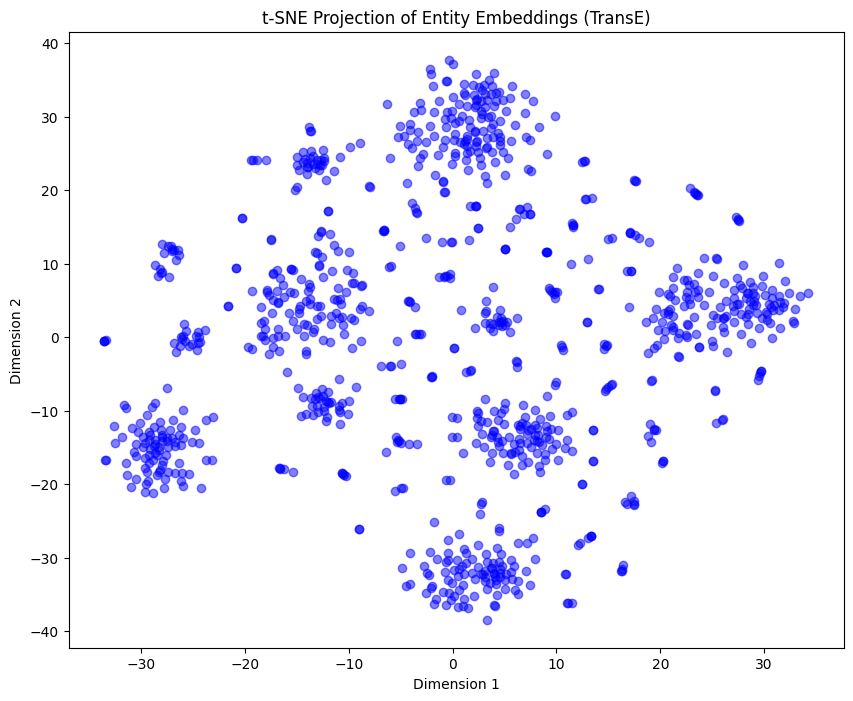

In [13]:
import matplotlib.pyplot as plt
from sklearn.manifold import TSNE
from sklearn.neighbors import NearestNeighbors
import torch

entity_embeddings = result_transe.model.entity_representations[0](indices=None).detach().cpu().numpy()
entity_ids = training_factory.entity_to_id
id_to_entity = {v: k for k, v in entity_ids.items()}

# Nearest neighbors
nn = NearestNeighbors(n_neighbors=4, metric='cosine')
nn.fit(entity_embeddings)

sample_entity_id = 0
distances, indices = nn.kneighbors([entity_embeddings[sample_entity_id]])

print(f"Nearest neighbors for: {id_to_entity[sample_entity_id]}")
for i in range(1, 4):
    print(f"{i}. {id_to_entity[indices[0][i]]} (Distance: {distances[0][i]:.4f})")

# t-SNE Visualization
tsne = TSNE(n_components=2, random_state=42)
embeddings_2d = tsne.fit_transform(entity_embeddings[:1000]) # Limited to 1000 for readability

plt.figure(figsize=(10, 8))
plt.scatter(embeddings_2d[:, 0], embeddings_2d[:, 1], alpha=0.5, c='blue')
plt.title("t-SNE Projection of Entity Embeddings (TransE)")
plt.xlabel("Dimension 1")
plt.ylabel("Dimension 2")
plt.show()

## Part 8: Comparison: Rule-based Reasoning vs. KGE (Vectors)
In TransE, composition relations can be approximated by vector addition: $e_{head} + r_1 \approx e_{inter}$ and $e_{inter} + r_2 \approx e_{tail}$, which implies $r_1 + r_2 \approx r_3$. We test this mathematical hypothesis directly on the learned relation embeddings.

In [14]:
relation_embeddings = result_transe.model.relation_representations[0](indices=None).detach().cpu().numpy()
relation_ids = training_factory.relation_to_id
id_to_rel = {v: k for k, v in relation_ids.items()}

if len(relation_ids) >= 3:
    r1_id, r2_id, r3_id = 0, 1, 2 # Replace with real IDs (e.g., hasSibling, Man, hasBrother)

    vec_r1 = relation_embeddings[r1_id]
    vec_r2 = relation_embeddings[r2_id]
    vec_target = relation_embeddings[r3_id]

    vec_composition = vec_r1 + vec_r2

    from scipy.spatial.distance import cosine
    sim = 1 - cosine(vec_composition, vec_target)

    print(f"Cosine similarity between ({id_to_rel[r1_id]} + {id_to_rel[r2_id]}) and {id_to_rel[r3_id]}: {sim:.4f}")

Cosine similarity between (http://wikiba.se/ontology#rank + http://www.w3.org/1999/02/22-rdf-syntax-ns#type) and http://www.w3.org/2000/01/rdf-schema#isDefinedBy: 0.1092
